In [1]:
import pandas as pd
import numpy as np
import os
import cv2
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Disable oneDNN custom operations logs for cleaner output
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Set aesthetic style for visuals
sns.set_theme(style="whitegrid")

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
PROCESSED_DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models' / 'vision_encoder'
VISUALS_DIR = PROJECT_ROOT / 'visualizations'

MODELS_DIR.mkdir(parents=True, exist_ok=True)
VISUALS_DIR.mkdir(parents=True, exist_ok=True)

print("Loading Master Vision Dataset Mapping...")
vision_path = PROCESSED_DATA_DIR / 'master_vision_data.csv'
df_vision = pd.read_csv(vision_path)

print(f"Vision Mapping Loaded. Total Records: {len(df_vision)}")

Loading Master Vision Dataset Mapping...
Vision Mapping Loaded. Total Records: 18678


In [2]:
print("Preparing Image Data Pipeline (Loading 64x64 Grayscale Images)...")

IMG_SIZE = 64

def load_and_preprocess_images(dataframe):
    images = []
    labels = []
    for index, row in dataframe.iterrows():
        img_path = row['image_path']
        label = 1 if row['label'] == 'Malware_Image' else 0
        
        # Read image in Grayscale to reduce channel depth from 3 to 1
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            # Resize and normalize pixel values to 0-1
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img / 255.0
            images.append(img)
            labels.append(label)
    
    # Reshape for CNN: (Samples, Height, Width, Channels)
    X = np.array(images).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
    y = np.array(labels)
    return X, y

X_vision, y_vision = load_and_preprocess_images(df_vision)
print(f"Total Images Successfully Loaded and Processed: {X_vision.shape[0]}")

# Stratified Split into 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X_vision, y_vision, test_size=0.2, random_state=42, stratify=y_vision)

print(f"Training Set Shape: {X_train.shape}")
print(f"Testing Set Shape: {X_test.shape}")

Preparing Image Data Pipeline (Loading 64x64 Grayscale Images)...
Total Images Successfully Loaded and Processed: 18678
Training Set Shape: (14942, 64, 64, 1)
Testing Set Shape: (3736, 64, 64, 1)


In [3]:
print("Building Advanced CNN Architecture...")

model = models.Sequential([
    # Layer 1: Feature Extraction
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.MaxPooling2D((2, 2)),
    
    # Layer 2: Deep Feature Extraction
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Layer 3: Deepest Features
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    
    # Fully Connected Brain
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3), # Prevent overfitting
    layers.Dense(1, activation='sigmoid') # Binary Output: 1 = Malware, 0 = Safe
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Building Advanced CNN Architecture...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 645,697 (2.46 MB)

 Trainable params: 645,697 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
print("Training the Vision AI Brain...")

# Stop early if the model stops improving on validation data, save the best weights
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train, 
    epochs=10, 
    batch_size=32, 
    validation_split=0.1, # Use 10% of train data to validate during training
    callbacks=[early_stop]
)

print("Training Phase Completed.")

Training the Vision AI Brain...
Epoch 1/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 47s 96ms/step - accuracy: 0.9978 - loss: 0.0165 - val_accuracy: 1.0000 - val_loss: 2.9066e-10
Epoch 2/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.9999 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss: 5.8513e-06
Epoch 3/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9999 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 2.5844e-09
Epoch 4/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9999 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss: 5.2664e-05
Training Phase Completed.


Evaluating Model Performance on Unseen Test Data...

Final Vision (CNN) Accuracy: 100.0000%
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

Detailed Classification Report:
                   precision    recall  f1-score   support

   Safe_Image (0)       1.00      1.00      1.00      1868
Malware_Image (1)       1.00      1.00      1.00      1868

         accuracy                           1.00      3736
        macro avg       1.00      1.00      1.00      3736
     weighted avg       1.00      1.00      1.00      3736



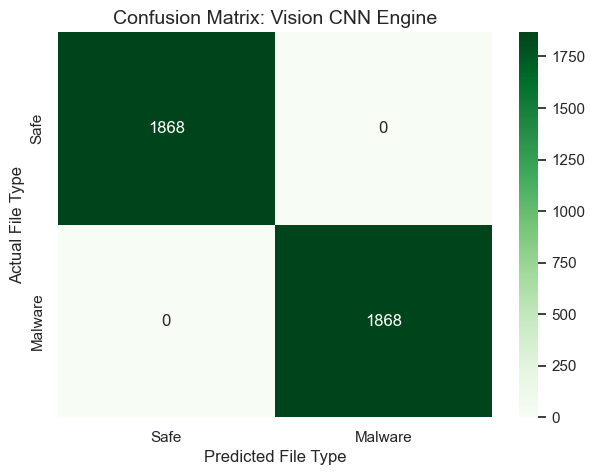

In [5]:
print("Evaluating Model Performance on Unseen Test Data...")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f"\nFinal Vision (CNN) Accuracy: {test_acc * 100:.4f}%")

y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Safe_Image (0)', 'Malware_Image (1)']))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Safe', 'Malware'], yticklabels=['Safe', 'Malware'])
plt.title('Confusion Matrix: Vision CNN Engine', fontsize=14)
plt.ylabel('Actual File Type', fontsize=12)
plt.xlabel('Predicted File Type', fontsize=12)
plt.savefig(VISUALS_DIR / '08_vision_model_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
print("Exporting Trained Vision Brain to Production...")
model_save_path = MODELS_DIR / 'cnn_vision_model.h5'
model.save(model_save_path)

print(f"AI Module 3 (Vision/CNN) trained and saved successfully at: {model_save_path}")

Exporting Trained Vision Brain to Production...
AI Module 3 (Vision/CNN) trained and saved successfully at: c:\Users\induw\OneDrive\Documents\SENTIO_360_Project\models\vision_encoder\cnn_vision_model.h5
